# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [1]:
# Import warnings



In [2]:
# Import the libraries you will be using for analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import pyarrow as pa
import pyarrow.parquet as pq
import os


In [3]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.0.2
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [4]:
# Try loading one file

# df = pd.read_parquet('2023-1.parquet')
# df.info()

#testing the dataframe with one file to check if all working fine
df1 = pd.read_parquet('/content/eda/2023-1.parquet')
df2= pd.read_parquet('/content/eda/2023-2.parquet')
df3 = pd.read_parquet('/content/eda/2023-3.parquet')
df4 = pd.read_parquet('/content/eda/2023-4.parquet')
df5 = pd.read_parquet('/content/eda/2023-5.parquet')
df6 = pd.read_parquet('/content/eda/2023-6.parquet')
df7 = pd.read_parquet('/content/eda/2023-7.parquet')
df8 = pd.read_parquet('/content/eda/2023-8.parquet')
df9 = pd.read_parquet('/content/eda/2023-9.parquet')
df10 = pd.read_parquet('/content/eda/2023-10.parquet')
df11 = pd.read_parquet('/content/eda/2023-11.parquet')
df12 = pd.read_parquet('/content/eda/2023-12.parquet')

df1.head()
df2.head()
df3.head()
df4.head()
df5.head()
df6.head()
df7.head()
df8.head()
df9.head()
df10.head()
df11.head()
df12.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,1,2023-12-01 00:06:06,2023-12-01 00:15:47,0.0,1.10,1.0,N,230,48,1,10.0,3.5,0.5,1.50,0.0,1.0,16.50,2.5,0.0
1,1,2023-12-01 00:22:26,2023-12-01 00:28:53,0.0,1.50,1.0,N,142,238,1,9.3,3.5,0.5,2.85,0.0,1.0,17.15,2.5,0.0
2,1,2023-12-01 00:59:44,2023-12-01 01:13:22,2.0,2.20,1.0,N,114,186,1,13.5,3.5,0.5,3.00,0.0,1.0,21.50,2.5,0.0
3,2,2023-12-01 00:22:17,2023-12-01 00:30:59,1.0,0.66,1.0,N,79,79,2,7.2,1.0,0.5,0.00,0.0,1.0,12.20,2.5,0.0
4,2,2023-12-01 00:18:16,2023-12-01 00:25:32,2.0,2.20,1.0,N,229,263,1,11.4,1.0,0.5,2.00,0.0,1.0,18.40,2.5,0.0


In [5]:
#print(f"Number of rows in '2023-1.parquet': {len(df_uploaded_file)}")

#to take a look of number of records in each of the 12 files provided

input_path="/content/eda/2023*.parquet"
parquet_files = glob.glob(input_path)

for file_path in parquet_files:
  df = pd.read_parquet(file_path, engine="pyarrow")
  print(f"number of records in the file {file_path}: {len(df)}")

number of records in the file /content/eda/2023-5.parquet: 2889185
number of records in the file /content/eda/2023-3.parquet: 3275796
number of records in the file /content/eda/2023-6.parquet: 3258261
number of records in the file /content/eda/2023-11.parquet: 3302857
number of records in the file /content/eda/2023-1.parquet: 3041714
number of records in the file /content/eda/2023-12.parquet: 3333925
number of records in the file /content/eda/2023-8.parquet: 2875947
number of records in the file /content/eda/2023-7.parquet: 3481547
number of records in the file /content/eda/2023-10.parquet: 3485185
number of records in the file /content/eda/2023-4.parquet: 2792901
number of records in the file /content/eda/2023-9.parquet: 2817156
number of records in the file /content/eda/2023-2.parquet: 3374086


How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [6]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload


In [7]:
# from google.colab import drive
# drive.mount('/content/drive')

In [10]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

input_path="/content/eda/2023*.parquet"
output_file="/content/sample_data/eda_output/sample_data.csv"

parquet_file=glob.glob(input_path)

if os.path.exists(output_file):
  os.remove(output_file)

writer= None

for i, parquet_file in enumerate(parquet_file):

  print("Processing the file : ", {parquet_file})

  df = pd.read_parquet(parquet_file, engine="pyarrow")

  df["pickup_date"] = df["tpep_pickup_datetime"].dt.date
  df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour

  sample_dataframe=(df.groupby(["pickup_date", "pickup_hour"], group_keys=False).apply(lambda x: x.sample(frac=0.007, random_state=42)))

  #sample_5df=df.sample(frac=.05, random_state=42)

  sample_dataframe.to_csv(
        output_file,
        mode="a",
        header=(i == 0),
        index=False
    )

print("final file with sample data from each file is created")

Processing the file :  {'/content/eda/2023-5.parquet'}


/tmp/ipython-input-673786775.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_dataframe=(df.groupby(["pickup_date", "pickup_hour"], group_keys=False).apply(lambda x: x.sample(frac=0.007, random_state=42)))


Processing the file :  {'/content/eda/2023-3.parquet'}


/tmp/ipython-input-673786775.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_dataframe=(df.groupby(["pickup_date", "pickup_hour"], group_keys=False).apply(lambda x: x.sample(frac=0.007, random_state=42)))


Processing the file :  {'/content/eda/2023-6.parquet'}


...

Processing the file :  {'/content/eda/2023-9.parquet'}


/tmp/ipython-input-673786775.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_dataframe=(df.groupby(["pickup_date", "pickup_hour"], group_keys=False).apply(lambda x: x.sample(frac=0.007, random_state=42)))


Processing the file :  {'/content/eda/2023-2.parquet'}


/tmp/ipython-input-673786775.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_dataframe=(df.groupby(["pickup_date", "pickup_hour"], group_keys=False).apply(lambda x: x.sample(frac=0.007, random_state=42)))


final file with sample data from each file is created


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [11]:
# Store the df in csv/parquet
# df.to_parquet('')
sample_df=pd.read_csv("/content/sample_data/eda_output/sample_data.csv")
sample_df.head()
print({len(sample_df)})

{265487}


## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [12]:

# Load the new data file
df = pd.read_csv('/content/sample_data/eda_output/sample_data.csv')



In [13]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_date,pickup_hour
0,2,2023-02-01 00:14:06,2023-02-01 00:19:52,3.0,1.25,1.0,N,234,114,1,...,1.0,0.5,6.12,0.0,1.0,19.72,2.5,0.0,2023-02-01,0
1,1,2023-02-01 00:54:09,2023-02-01 01:13:13,1.0,5.00,1.0,N,48,87,1,...,3.5,0.5,0.00,0.0,1.0,28.30,2.5,0.0,2023-02-01,0
2,2,2023-02-01 00:14:36,2023-02-01 00:59:16,1.0,24.04,1.0,N,114,121,1,...,1.0,0.5,6.00,0.0,1.0,102.20,2.5,0.0,2023-02-01,0
3,1,2023-02-01 00:49:25,2023-02-01 00:53:12,1.0,0.60,1.0,N,246,68,1,...,3.5,0.5,1.00,0.0,1.0,11.80,2.5,0.0,2023-02-01,0
4,1,2023-02-01 00:16:02,2023-02-01 00:22:02,1.0,0.90,1.0,N,114,148,1,...,3.5,0.5,2.55,0.0,1.0,15.45,2.5,0.0,2023-02-01,0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265487 entries, 0 to 265486
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               265487 non-null  int64  
 1   tpep_pickup_datetime   265487 non-null  object 
 2   tpep_dropoff_datetime  265487 non-null  object 
 3   passenger_count        256656 non-null  float64
 4   trip_distance          265487 non-null  float64
 5   RatecodeID             256656 non-null  float64
 6   store_and_fwd_flag     256656 non-null  object 
 7   PULocationID           265487 non-null  int64  
 8   DOLocationID           265487 non-null  int64  
 9   payment_type           265487 non-null  int64  
 10  fare_amount            265487 non-null  float64
 11  extra                  265487 non-null  float64
 12  mta_tax                265487 non-null  float64
 13  tip_amount             265487 non-null  float64
 14  tolls_amount           265487 non-nu

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [15]:
# Fix the index and drop any columns that are not needed

#the data is clean at the moment and no action is required as we are yet to start with the EDA. Based on progress the data will be cleaned and streamlined.

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [16]:
# Combine the two airport fee columns

#Based on the method used to read each file one at a time and sample the data .007 fraction at a time then writing the same into the csv file. This way the first file header is used in the csv file. we see that 2023-1.parquet file has airtpot_fee in small and all other files have Airport_fee. Hence the csv contains only Airport_fee column only. so no action is required to merge the columns and we see only 1 Airport_fee column created in the sampled data.

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [17]:
# check where values of fare amount are negative
df[df['fare_amount'] < 0]



,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_date,pickup_hour


Did you notice something different in the `RatecodeID` column for above records?

In [18]:
# Analyse RatecodeID for the negative fare amounts



In [19]:
# Find which columns have negative values
#analyzing the final sampled data to check if any column that should hold numemonetary values are having negetive values or non numeric values

df = pd.read_csv("/content/sample_data/eda_output/sample_data.csv")

monetary_columns =[
    'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount',
    'improvement_surcharge', 'total_amount',
    'congestion_surcharge', 'Airport_fee'
]

results =[]

for columns in monetary_columns:
  numeric_column = pd.to_numeric(df[columns], errors='coerce')
  negative_count = (numeric_column < 0).sum()
  results.append({
      "column": columns,
      "negative_values": negative_count
      })

# Create summary dataframe
summary_df = pd.DataFrame(results)

print(summary_df)




                  column  negative_values
0            fare_amount                0
1                  extra                1
2                mta_tax               11
3             tip_amount                0
4           tolls_amount                0
5  improvement_surcharge               11
6           total_amount               11
7   congestion_surcharge                6
8            Airport_fee                2


In [20]:
# fix these negative values

# as in above section

### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [21]:

# Find the proportion of missing values in each column

missing_val_column = df.isnull().sum()
missing_val_column_percentage = (missing_val_column / len(df)) * 100

df_missing_info = pd.DataFrame({
    'Missing Values In Column': missing_val_column,
    'Missing Values Percentage': missing_val_column_percentage
})

print(df_missing_info[df_missing_info['Missing Values In Column'] > 0].sort_values(by='Missing Values Percentage', ascending=False))



                      Missing Values In Column  Missing Values Percentage
passenger_count                           8831                    3.32634
RatecodeID                                8831                    3.32634
store_and_fwd_flag                        8831                    3.32634
congestion_surcharge                      8831                    3.32634
Airport_fee                               8831                    3.32634


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [22]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'
# Print the records with Null value as 'passenger_count'
print("Record with null value in column 'passenger_count':")
print(df[df['passenger_count'].isnull()].head())

#Replace Null value in passenger count has to be decided by the mathematical calculation and not just by 1 or any other number.
#replaceing the null value with MODE value can be near correct value based on data assumption

#checking the data distribution of the passenger count in data frame.

print("passenget count distribution:")
print(df['passenger_count'].value_counts(dropna=False))

# replaceing  the paseenger count with the Mode value as it is the nearest and most scientifically supported data
mode_of_passenger_count = df['passenger_count'].mode()[0]
df['passenger_count'] = df['passenger_count'].fillna(mode_of_passenger_count)
print(f"null value of passenger count is replaced with : {mode_of_passenger_count} which is the MODE of passenger count as per calculation")

# check for records with passenger count mentioned as 0
print("\nNumber of records with passenger count mentioned as 0:", (df['passenger_count'] == 0).sum())

# replace passenger count from 0 to 1 as each ride has minimum 1 passenger
df['passenger_count'] = df['passenger_count'].replace(0, 1)
print("Number of records with passenger count mentioned as 0 updated to 1:", (df['passenger_count'] == 0).sum())

# Check for nulls values after replacement of null values and 0 value in passenger count with MODE and 1 respectively.
print("count of null 'passenger_count' after replacement of null values and 0 value in passenger count with MODE and 1:", df['passenger_count'].isnull().sum())

Record with null value in column 'passenger_count':
    VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
12         2  2023-02-01 01:46:13   2023-02-01 01:59:11              NaN   
21         1  2023-02-01 05:28:00   2023-02-01 05:33:34              NaN   
35         2  2023-02-01 06:57:26   2023-02-01 07:04:46              NaN   
41         2  2023-02-01 07:57:51   2023-02-01 08:23:13              NaN   
58         2  2023-02-01 07:51:43   2023-02-01 08:03:48              NaN   

    trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
12           2.98         NaN                NaN           114            33   
21           1.40         NaN                NaN           141           162   
35           3.87         NaN                NaN            75           179   
41           4.05         NaN                NaN           239           234   
58           2.13         NaN                NaN           143           246   

    paymen

Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [23]:
# Fix missing values in 'RatecodeID'
# Fixing the missing values in 'RatecodeID'

# in order to decide the replacement method for missing value in RateCodeId analysing the data
print("Distribution of 'RatecodeID':")
print(df['RatecodeID'].value_counts(dropna=False))

# According to the data dictionary:
# 1 = Standard rate
# 2 = JFK
# 3 = Newark
# 4 = Nassau or Westchester
# 5 = Negotiated fare
# 6 = Group ride

# replaceing the missing value in RateCodeId by MODE as it defines the mathematical support to replace the NULL values in the column
RateCodeId_mode = df['RatecodeID'].mode()[0]
df['RatecodeID'] = df['RatecodeID'].fillna(RateCodeId_mode)
print(f"missing or null values in RateCodeId is replaced with mode: {RateCodeId_mode}")

# analysing the data to check for null values in RateCodeId after it is replaced with MODE value
print("\nNull values in 'RatecodeID' after it is replaced with MODE value:", df['RatecodeID'].isnull().sum())

Distribution of 'RatecodeID':
RatecodeID
1.0     242253
2.0      10081
NaN       8831
99.0      1530
5.0       1428
3.0        845
4.0        519
Name: count, dtype: int64
missing or null values in RateCodeId is replaced with mode: 1.0

Null values in 'RatecodeID' after it is replaced with MODE value: 0


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [24]:
# handle null values in congestion_surcharge

# handling null values in congestion_surcharge column

# analysing the data for clolumn congestion-surcharge to replace null values accordingly
print("pattern distribution of 'congestion_surcharge':")
print(df['congestion_surcharge'].value_counts(dropna=False))

# with respect to surcharge Nan may infer to no surcharge. hence it can be replaced with 0
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(0.0)
print("\nmissing  values in 'congestion_surcharge' is replaced with 0.0")

# Checking the congestation surcharge column if any missing value still remains after replacement by 0
print("missing values in 'congestion_surcharge' after replacement with 0:", df['congestion_surcharge'].isnull().sum())


pattern distribution of 'congestion_surcharge':
congestion_surcharge
 2.5    236938
 0.0     19712
 NaN      8831
-2.5         6
Name: count, dtype: int64

missing  values in 'congestion_surcharge' is replaced with 0.0
missing values in 'congestion_surcharge' after replacement with 0: 0


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [25]:
# Handle any remaining missing values
# managing the missing values in other columns

# analysing the data to replace missing values in 'store_and_fwd_flag'

print("Pattern of 'store_and_fwd_flag':")
print(df['store_and_fwd_flag'].value_counts(dropna=False))

# replace the missing value with MODE value i.e. N
StoreAndFwdFlag = df['store_and_fwd_flag'].mode()[0]
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna(StoreAndFwdFlag)
print("missing values has been replaced with mode value: {StoreAndFwdFlag}")

# analysing the data to replace missing values in 'airport_fee'

print("Pattern of 'Airport_fee':")
print(df['Airport_fee'].value_counts(dropna=False))

# If airport_fee is NaN, it means no airport fee was charged for that trip

df['Airport_fee'] = df['Airport_fee'].fillna(0.0)
print("missing values in 'Airport_fee' colunn is replaced by 0.0")

# Verify that all missing values have been taken care off
print("missing values in 'Airport_fee' colunn is replaced by 0.0")
print(df.isnull().sum()[df.isnull().sum() > 0])


Pattern of 'store_and_fwd_flag':
store_and_fwd_flag
N      255146
NaN      8831
Y        1510
Name: count, dtype: int64
missing values has been replaced with mode value: {StoreAndFwdFlag}
Pattern of 'Airport_fee':
Airport_fee
 0.00    234050
 1.75     16911
 NaN       8831
 1.25      5693
-1.75         2
Name: count, dtype: int64
missing values in 'Airport_fee' colunn is replaced by 0.0
missing values in 'Airport_fee' colunn is replaced by 0.0
Series([], dtype: int64)


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [26]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns
# analysing the data for checking presence of outlier
print(df.describe().T)

# perform analysis to check if any outlier is present in the column

print("count of payment_type:")
print(df['payment_type'].value_counts())

print("count of RatecodeID:")
print(df['RatecodeID'].value_counts())

print("look for trips with 0 distance and non zero fare")
print(df[(df['trip_distance'] == 0) & (df['fare_amount'] > 0)].shape[0])

print("checking for distnce of trip < 1 km and trip fare >200")
print(df[(df['fare_amount'] > 300) & (df['trip_distance'] < 1)].shape[0])


                          count        mean        std   min     25%     50%  \
VendorID               265487.0    1.733475   0.447562  1.00    1.00    2.00   
passenger_count        265487.0    1.370538   0.862992  1.00    1.00    1.00   
trip_distance          265487.0    3.581805  48.595892  0.00    1.05    1.80   
RatecodeID             265487.0    1.636491   7.422751  1.00    1.00    1.00   
PULocationID           265487.0  165.172668  64.070411  1.00  132.00  162.00   
DOLocationID           265487.0  163.952988  69.779730  1.00  113.00  162.00   
payment_type           265487.0    1.164980   0.506647  0.00    1.00    1.00   
fare_amount            265487.0   19.830154  18.204986  0.00    9.30   13.50   
extra                  265487.0    1.587679   1.824932 -2.50    0.00    1.00   
mta_tax                265487.0    0.495325   0.048416 -0.50    0.50    0.50   
tip_amount             265487.0    3.548453   4.046095  0.00    1.00    2.84   
tolls_amount           265487.0    0.593

**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [27]:
# remove passenger_count > 6
# Passenger count greater than 6 are invalid entry so needs to be removed
# did not find any such record in the data frame hence skipping this analysis step.

In [28]:
# Continue with outlier handling
# Trip distance with non-zero fare
print(f"Rows with 0 trip_distance and fare_amount > 0 before removal: {len(df[(df['trip_distance'] == 0) & (df['fare_amount'] > 0)])}")
df = df[~((df['trip_distance'] == 0) & (df['fare_amount'] > 0))]
print(f"Rows after removing zero trip_distance and fare_amount > 0: {len(df)}")

# RatecodeID with value 99.0 is invalid entry.
print(f"Rows RatecodeID with value 99.0 before removal: {len(df[df['RatecodeID'] == 99.0])}")
df = df[df['RatecodeID'] != 99.0]
print(f"Rows after removing RatecodeID with value 99.0: {len(df)}")

# Handle trip_distance > 250 miles (usually outliers for NYC taxi data)
print(f"Rows with trip_distance > 250 miles before removal: {len(df[df['trip_distance'] > 250])}")
df = df[df['trip_distance'] <= 250]
print(f"Rows after removing extreme trip_distance: {len(df)}")

# Payment_type with value 0 is undefined
print(f"Number of Rows with payment_type 0 before removal: {len(df[df['payment_type'] == 0])}")
df = df[df['payment_type'] != 0]
print(f"Rows after removing payment_type having vallue as 0: {len(df)}")

# Handle 0 trip distance and 0 fare amount but different pickup/dropoff zones meaning invalid trips with respect to drops and pickup

print(f"Rows with 0 trip_distance, zero fare_amount, and different zones before removal: {len(df[(df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID'])])}")
df = df[~((df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID']))]
print(f"Rows after removing these invalid trips: {len(df)}")


Rows with 0 trip_distance and fare_amount > 0 before removal: 5226
Rows after removing zero trip_distance and fare_amount > 0: 260261
Rows RatecodeID with value 99.0 before removal: 1380
Rows after removing RatecodeID with value 99.0: 258881
Rows with trip_distance > 250 miles before removal: 3
Rows after removing extreme trip_distance: 258878
Number of Rows with payment_type 0 before removal: 6745
Rows after removing payment_type having vallue as 0: 252133
Rows with 0 trip_distance, zero fare_amount, and different zones before removal: 3
Rows after removing these invalid trips: 252130


In [29]:
# Do any columns need standardising?



## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [30]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'Airport_fee',
 'pickup_date',
 'pickup_hour']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

Categorise the varaibles into Numerical or Categorical.
VendorID: Categorical
tpep_pickup_datetime:Numerical
tpep_dropoff_datetime:Numerical
passenger_count:Numerical
trip_distance:Numerical
RatecodeID:Categorical
PULocationID:Categorical
DOLocationID:Categorical
payment_type:Categorical
pickup_hour:Categorical
trip_duration:Numerical



The following monetary parameters belong in the same category, is it categorical or numerical?
fare_amount - Numerical 
extra - Numerical 
mta_tax - Numerical 
tip_amount - Numerical 
tolls_amount - Numerical 
improvement_surcharge - Numerical 
total_amount - Numerical 
congestion_surcharge - Numerical 
airport_fee - Numerical


##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

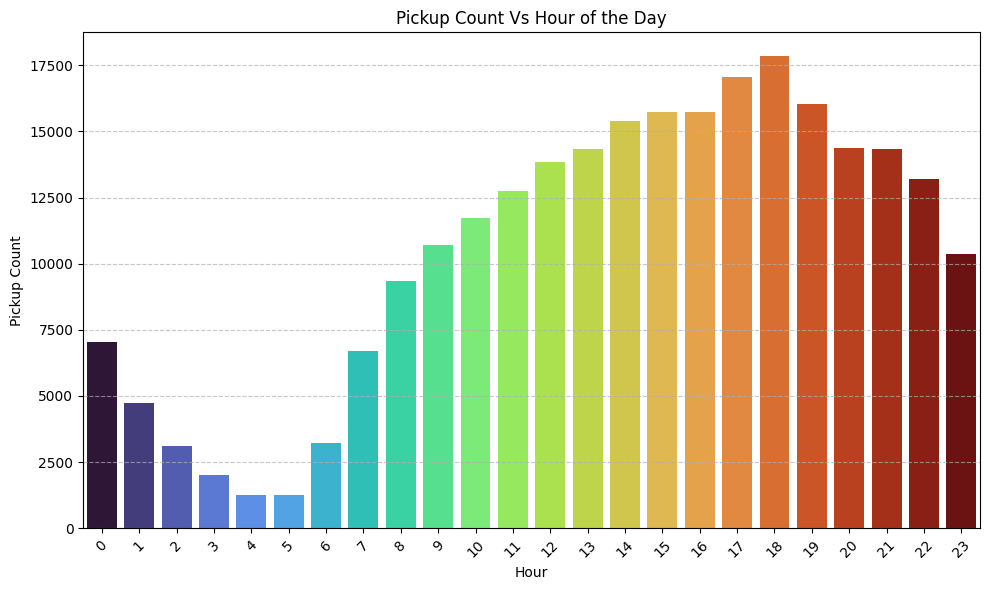

In [31]:
# Find and show the hourly trends in taxi pickups

df.head()
#Checked the pickup hour and pickup date column was created during the exercise of sampleing the data hence no further action required for creation of the aforsaid columns.

# Calculate hourly trends
hourwise_pickup_count = df['pickup_hour'].value_counts().sort_index()

# Visualize hourly trends
plt.figure(figsize=(10, 6))
sns.barplot(x=hourwise_pickup_count.index, y=hourwise_pickup_count.values, palette='turbo', hue=hourwise_pickup_count.index, legend=False)
plt.title('Pickup Count Vs Hour of the Day')
plt.xlabel('Hour')
plt.ylabel('Pickup Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

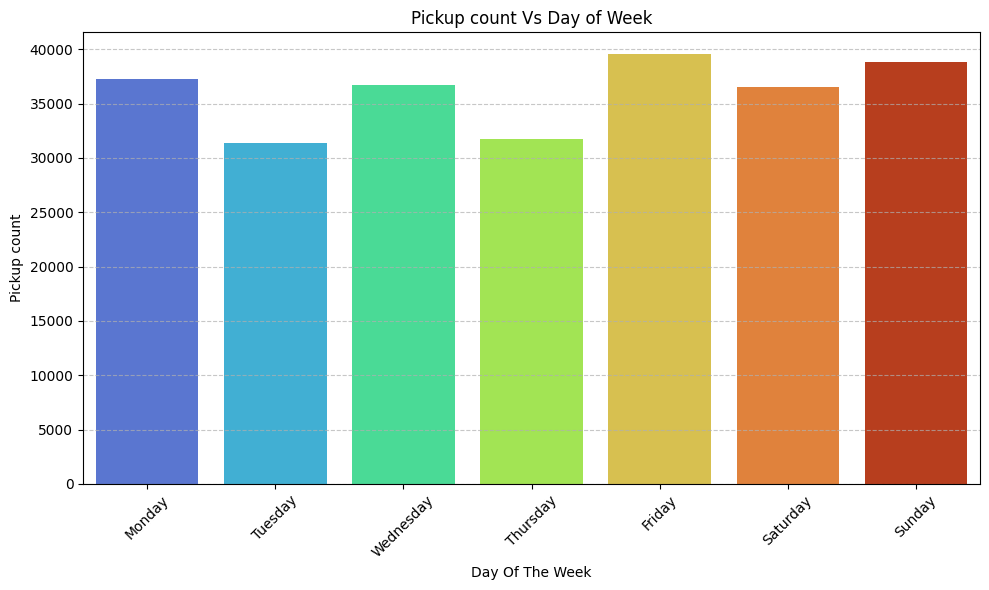

In [32]:
# Find and show the daily trends in taxi pickups (days of the week)

# trend of pick up day of the weekwise by plotting count of pickups daywise
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"],errors="coerce")

df["dayofweek"] = df["tpep_pickup_datetime"].dt.day_name()

daily_pickups = df['dayofweek'].value_counts().sort_index()

day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 6))
sns.barplot(x=daily_pickups.index, y=daily_pickups.values, palette='turbo', hue=daily_pickups.index, legend=False)
plt.title('Pickup count Vs Day of Week')
plt.xlabel('Day Of The Week')
plt.ylabel('Pickup count')
plt.xticks(ticks=daily_pickups.index, labels=day_names, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

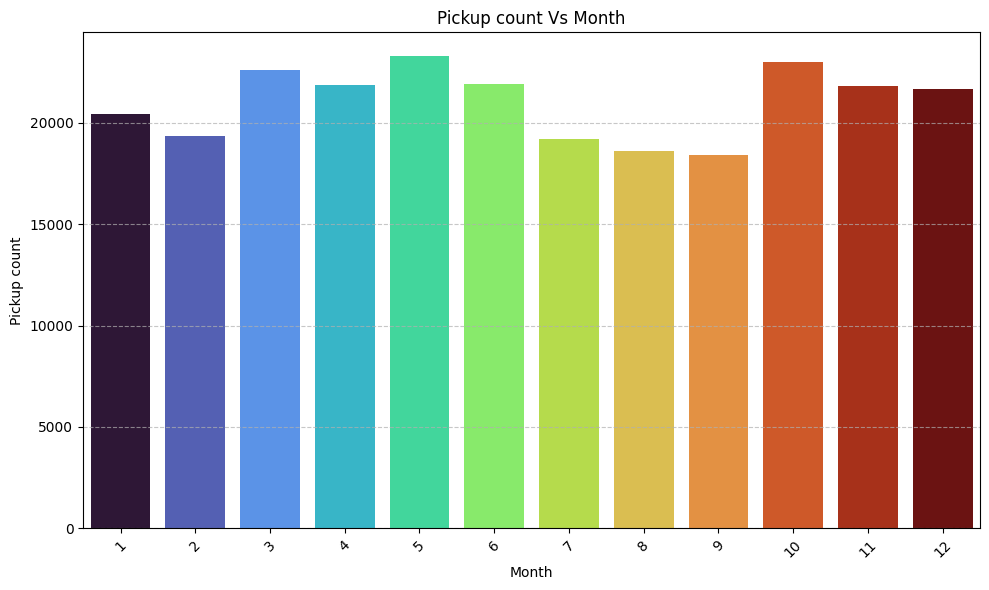

In [33]:
# Show the monthly trends in pickups

# Momnthwise pickup trend

df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"],errors="coerce")
df['month'] = df['tpep_pickup_datetime'].dt.month
pickup_count_monthly = df['month'].value_counts().sort_index()

month_name = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(10, 6))
sns.barplot(x=pickup_count_monthly.index, y=pickup_count_monthly.values, palette='turbo', hue=pickup_count_monthly.index, legend=False)
plt.title('Pickup count Vs Month')
plt.xlabel('Month')
plt.ylabel('Pickup count')
plt.xticks( rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [34]:

# Analyse the above parameters

print("Occurance of 0 in fare_amount column:", (df['fare_amount'] == 0).sum())
print("Occurance of 0 in tip_amount column:", (df['tip_amount'] == 0).sum())
print("Occurance of 0 in total_amount column:", (df['total_amount'] == 0).sum())
print("Occurance of 0 in trip_distance column:", (df['trip_distance'] == 0).sum())


Occurance of 0 in fare_amount column: 83
Occurance of 0 in tip_amount column: 54068
Occurance of 0 in total_amount column: 28
Occurance of 0 in trip_distance column: 32


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [35]:
# Create a df with non zero entries for the selected parameters.
# Creata copy of the dataframe which was created over the sampled data
df_financial = df.copy()

# filtering the records where fare_amount, tip_amount, total_amount, or trip_distance are zero
# Considering a 0 tip is a valid outcome, but for 'analysis of tipping behaviour' it can be useful to filter.
df_financial = df_financial[df_financial['total_amount'] > 0]
df_financial = df_financial[df_financial['fare_amount'] > 0]
df_financial = df_financial[df_financial['tip_amount'] > 0]
df_financial = df_financial[df_financial['trip_distance'] > 0]

print(f"number of records in original dataframe: {len(df)}")
print(f"number of records in financial dataframe after removing the 0 value records: {len(df_financial)}")



number of records in original dataframe: 252130
number of records in financial dataframe after removing the 0 value records: 198056


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

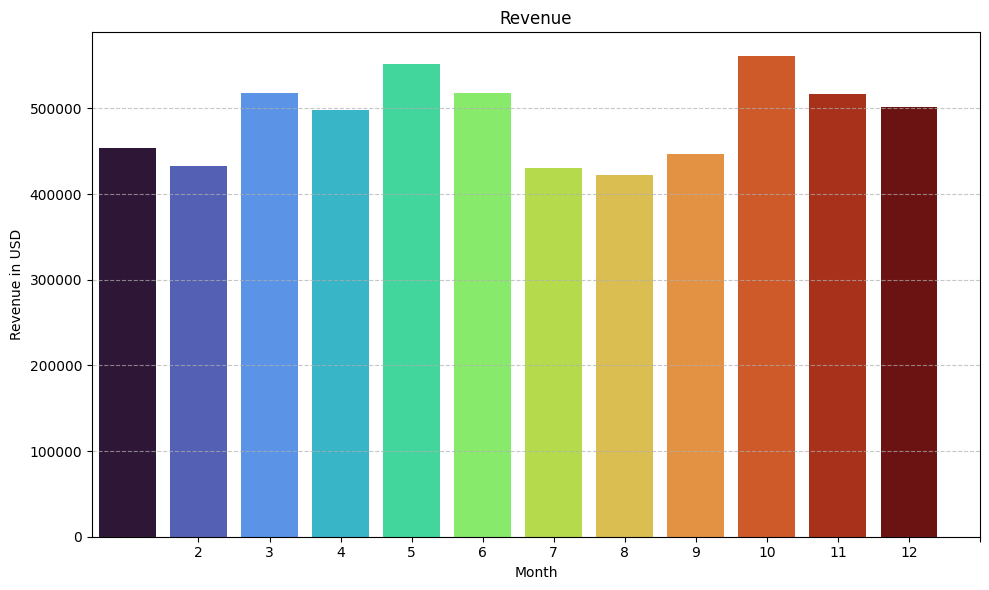

In [36]:
# Group data by month and analyse monthly revenue


df_financial['month'] = df_financial['tpep_pickup_datetime'].dt.month
month_wise_revenue = df_financial.groupby('month')['total_amount'].sum()

plt.figure(figsize=(10, 6))
sns.barplot(x=month_wise_revenue.index, y=month_wise_revenue.values, palette='turbo', hue=month_wise_revenue.index, legend=False)
plt.title('Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue in USD')
plt.xticks(month_wise_revenue.index)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

Revenue Proportion per quarter(%):
quarter
1    1404810.04
2    1568571.55
3    1300214.52
4    1579849.10
Name: total_amount, dtype: float64


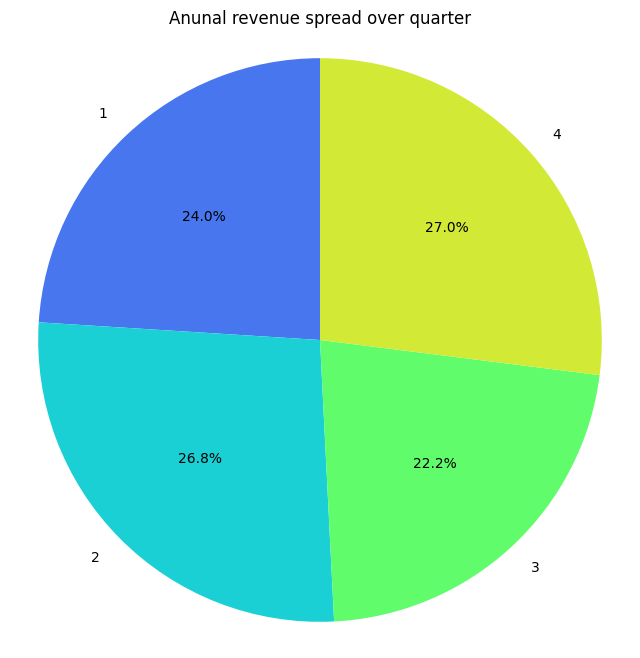

In [37]:
# Calculate proportion of each quarter
# Calculate quarterly revenue


# adding a new column 'Quarter' in the dataframe
df_financial['quarter'] = df_financial['tpep_pickup_datetime'].dt.quarter

# Calculate total revenue per quarter
revenue_per_quarter = df_financial.groupby('quarter')['total_amount'].sum()

# Calculate the proportion of each quarter in the total revenue
annual_revenue = revenue_per_quarter.sum()
quarterly_revenue = (revenue_per_quarter / annual_revenue) * 100

print("Revenue Proportion per quarter(%):")
print(revenue_per_quarter)

# Visualize the proportion
plt.figure(figsize=(8, 8))
plt.pie(revenue_per_quarter, labels=revenue_per_quarter.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('turbo'))
plt.title('Anunal revenue spread over quarter')
plt.axis('equal')
plt.show()


**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

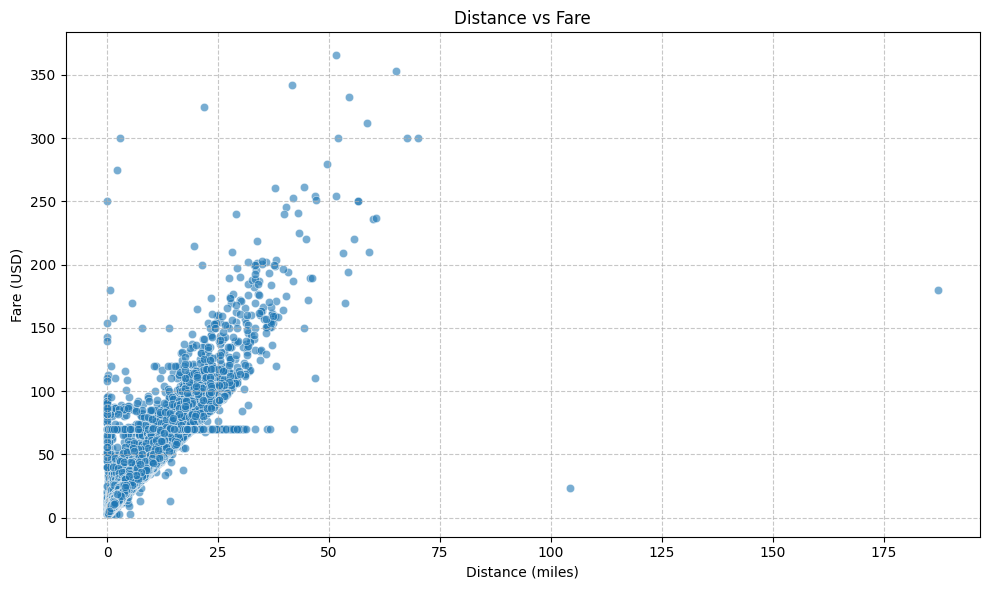

Correlation between trip_distance and fare_amount: 0.95


In [38]:
# Show how trip fare is affected by distance

# impact of distance on trip fare

# remove records with trips with distance =0 as it will negetively impact the analysis
df_financial_filtered = df_financial[df_financial['trip_distance'] > 0]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='trip_distance', y='fare_amount', data=df_financial_filtered, alpha=0.6)
plt.title('Distance vs Fare')
plt.xlabel('Distance (miles)')
plt.ylabel('Fare (USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Calculate the correlation
correlation = df_financial_filtered['trip_distance'].corr(df_financial_filtered['fare_amount'])
print(f"Correlation between trip_distance and fare_amount: {correlation:.2f}")

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

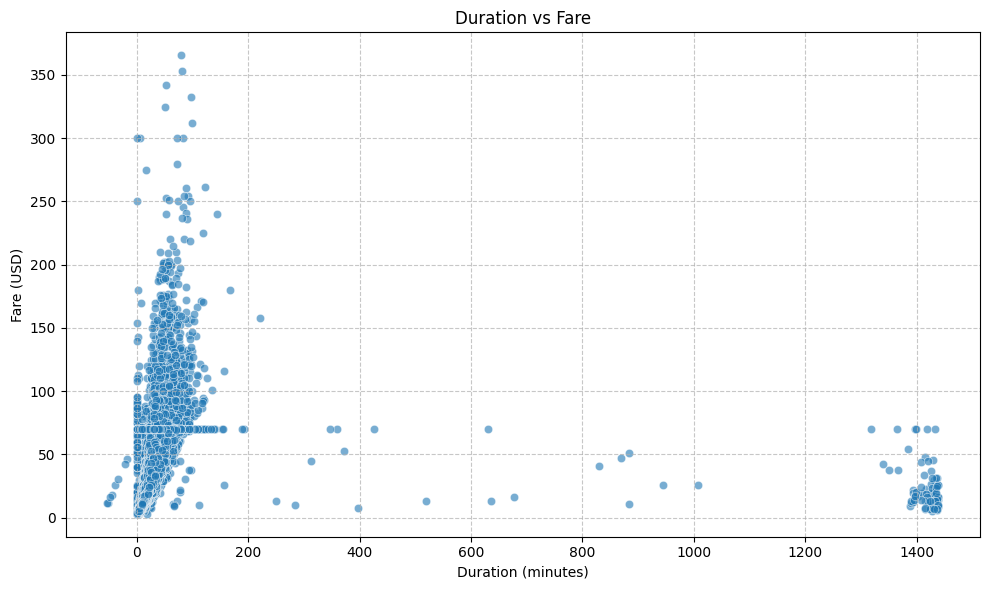

Correlation trip_duration Vs  fare_amount: 0.33


In [39]:
# Show relationship between fare and trip duration

# fare and trip duration relation

# trip duration in minutes

for d in [df, df_financial_filtered]:
    d["tpep_pickup_datetime"] = pd.to_datetime(d["tpep_pickup_datetime"], errors="coerce")
    d["tpep_dropoff_datetime"] = pd.to_datetime(d["tpep_dropoff_datetime"], errors="coerce")

    d["trip_duration"] = (
        d["tpep_dropoff_datetime"] - d["tpep_pickup_datetime"]
    ).dt.total_seconds() / 60
plt.figure(figsize=(10, 6))
sns.scatterplot(x='trip_duration', y='fare_amount', data=df_financial_filtered, alpha=0.6)
plt.title('Duration vs Fare')
plt.xlabel('Duration (minutes)')
plt.ylabel('Fare (USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Calculate the correlation
correlation_fare_duration = df_financial_filtered['trip_duration'].corr(df_financial_filtered['fare_amount'])
print(f"Correlation trip_duration Vs  fare_amount: {correlation_fare_duration:.2f}")

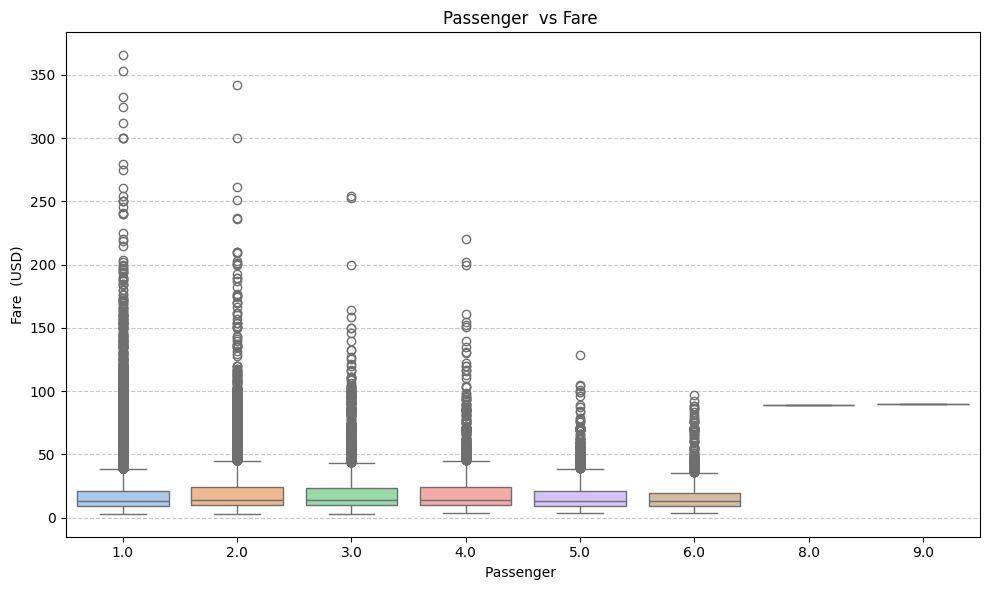

Correlation  passenger_count vs fare_amount: 0.04


In [40]:
# Show relationship between fare and number of passengers
# relationship  fare vs number of passengers

plt.figure(figsize=(10, 6))
sns.boxplot(x='passenger_count', y='fare_amount', data=df_financial, palette='pastel', hue='passenger_count', legend=False)
plt.title('Passenger  vs Fare ')
plt.xlabel('Passenger ')
plt.ylabel('Fare  (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Calculate the correlation (Pearson correlation for numerical variables)
correlation_fare_passenger = df_financial['passenger_count'].corr(df_financial['fare_amount'])
print(f"Correlation  passenger_count vs fare_amount: {correlation_fare_passenger:.2f}")


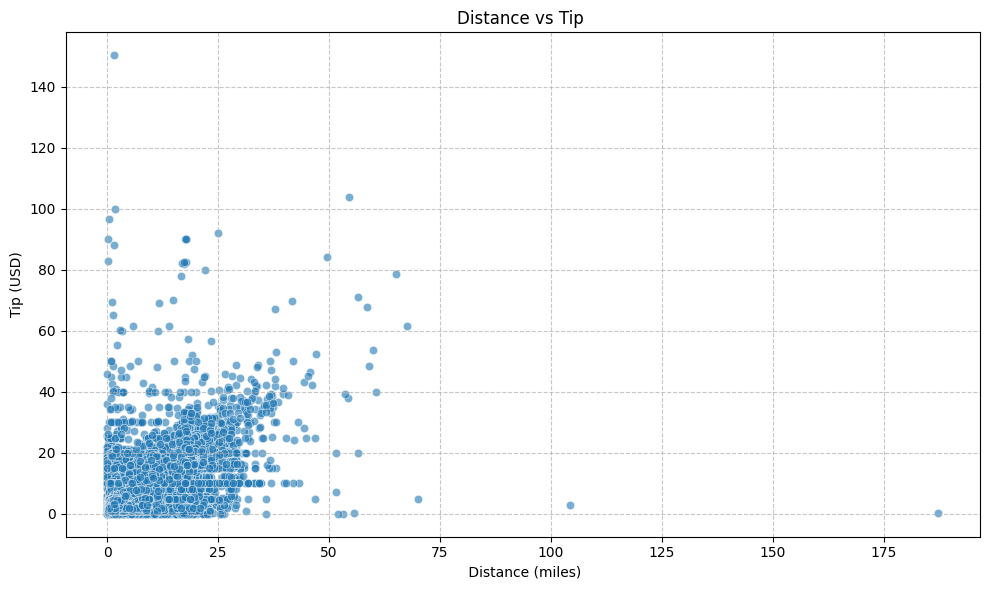

Correlation  trip_distance vs tip_amount: 0.80


In [41]:
# Show relationship between tip and trip distance

# relationship  tip vs trip distance

plt.figure(figsize=(10, 6))
sns.scatterplot(x='trip_distance', y='tip_amount', data=df_financial, alpha=0.6)
plt.title('Distance vs Tip ')
plt.xlabel(' Distance (miles)')
plt.ylabel('Tip (USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Calculate the correlation
correlation_tip_distance = df_financial['trip_distance'].corr(df_financial['tip_amount'])
print(f"Correlation  trip_distance vs tip_amount: {correlation_tip_distance:.2f}")

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

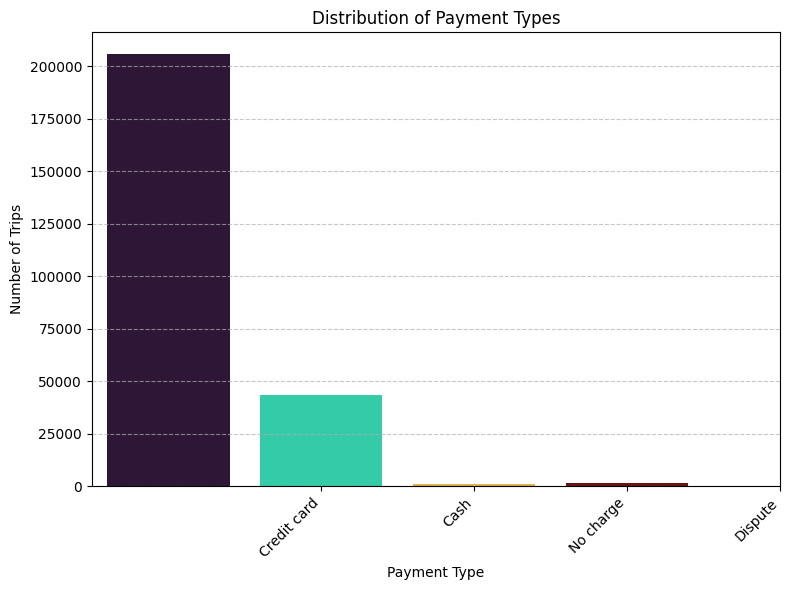

Distribution of Payment Types:
payment_type
1    205887
2     43590
4      1715
3       938
Name: count, dtype: int64


In [42]:
# Analyse the distribution of different payment types (payment_type).

# Analyse of different payment types (payment_type).

# value counts for payment_type
count_payment_type = df['payment_type'].value_counts()

#  payment type codes mapping
payment_type_map = {
    1: 'Credit card',
    2: 'Cash',
    3: 'No charge',
    4: 'Dispute',
    # 5: 'Unknown', # Removed 0, 5, 6 during data cleaning
    # 6: 'Voided trip'
}

payment_type_labels = [payment_type_map.get(pt, f'Unknown ({pt})') for pt in count_payment_type.index]

plt.figure(figsize=(8, 6))
sns.barplot(x=count_payment_type.index, y=count_payment_type.values, palette='turbo', hue=count_payment_type.index, legend=False)
plt.title('Distribution of Payment Types')
plt.xlabel('Payment Type')
plt.ylabel('Number of Trips')
plt.xticks(ticks=count_payment_type.index, labels=payment_type_labels, rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Distribution of Payment Types:")
print(count_payment_type)



- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [43]:
# !pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [48]:
# import geopandas as gpd


# Read the shapefile using geopandas
zones = pandas.read_file('/content/eda/taxi_zones.shp')
zones.head()

NameError: name 'pandas' is not defined

Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

In [49]:
# print(zones.info())
# zones.plot()
import geopandas as gpd
import matplotlib.pyplot as plt
os.chdir('/content/eda')
# Read the shapefile using geopandas
zones = gpd.read_file('taxi_zones.shp')
zones.head()


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [50]:
# Merge zones and trip records using locationID and PULocationID

# Merging the  zones and trip records by using locationID and PULocationID in zones and sample dataframe
merged_df = pd.merge(df, zones, left_on='PULocationID', right_on='LocationID', how='left')
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252137 entries, 0 to 252136
Data columns (total 31 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               252137 non-null  int64         
 1   tpep_pickup_datetime   252137 non-null  datetime64[ns]
 2   tpep_dropoff_datetime  252137 non-null  datetime64[ns]
 3   passenger_count        252137 non-null  float64       
 4   trip_distance          252137 non-null  float64       
 5   RatecodeID             252137 non-null  float64       
 6   store_and_fwd_flag     252137 non-null  object        
 7   PULocationID           252137 non-null  int64         
 8   DOLocationID           252137 non-null  int64         
 9   payment_type           252137 non-null  int64         
 10  fare_amount            252137 non-null  float64       
 11  extra                  252137 non-null  float64       
 12  mta_tax                252137 non-null  floa

**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [51]:
# Group data by location and calculate the number of trips

# Grouping the  data by location and calculation of number of trips
trips_zone = merged_df['PULocationID'].value_counts().reset_index()
trips_zone.columns = ['PULocationID', 'trip_count']
print("Top 10 zones by trip count:")
print(trips_zone.head(10))

Top 10 zones by trip count:
   PULocationID  trip_count
0           132       13336
1           237       12065
2           161       11954
3           236       10749
4           162        9230
5           138        8901
6           186        8679
7           230        8486
8           142        8306
9           170        7493


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [52]:
# Merge trip counts back to the zones GeoDataFrame

zones_trips = pd.merge(zones, trips_zone, left_on='LocationID', right_on='PULocationID', how='left')

# Fill NaN trip counts (for zones with no pickups) with 0
zones_trips['trip_count'] = zones_trips['trip_count'].fillna(0)

print("Zones GeoDataFrame with trip counts:")
print(zones_trips.head())


Zones GeoDataFrame with trip counts:
   OBJECTID  Shape_Leng  Shape_Area                     zone  LocationID  \
0         1    0.116357    0.000782           Newark Airport           1   
1         2    0.433470    0.004866              Jamaica Bay           2   
2         3    0.084341    0.000314  Allerton/Pelham Gardens           3   
3         4    0.043567    0.000112            Alphabet City           4   
4         5    0.092146    0.000498            Arden Heights           5   

         borough                                           geometry  \
0            EWR  POLYGON ((933100.918 192536.086, 933091.011 19...   
1         Queens  MULTIPOLYGON (((1033269.244 172126.008, 103343...   
2          Bronx  POLYGON ((1026308.77 256767.698, 1026495.593 2...   
3      Manhattan  POLYGON ((992073.467 203714.076, 992068.667 20...   
4  Staten Island  POLYGON ((935843.31 144283.336, 936046.565 144...   

   PULocationID  trip_count  
0           1.0         5.0  
1           NaN    

The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

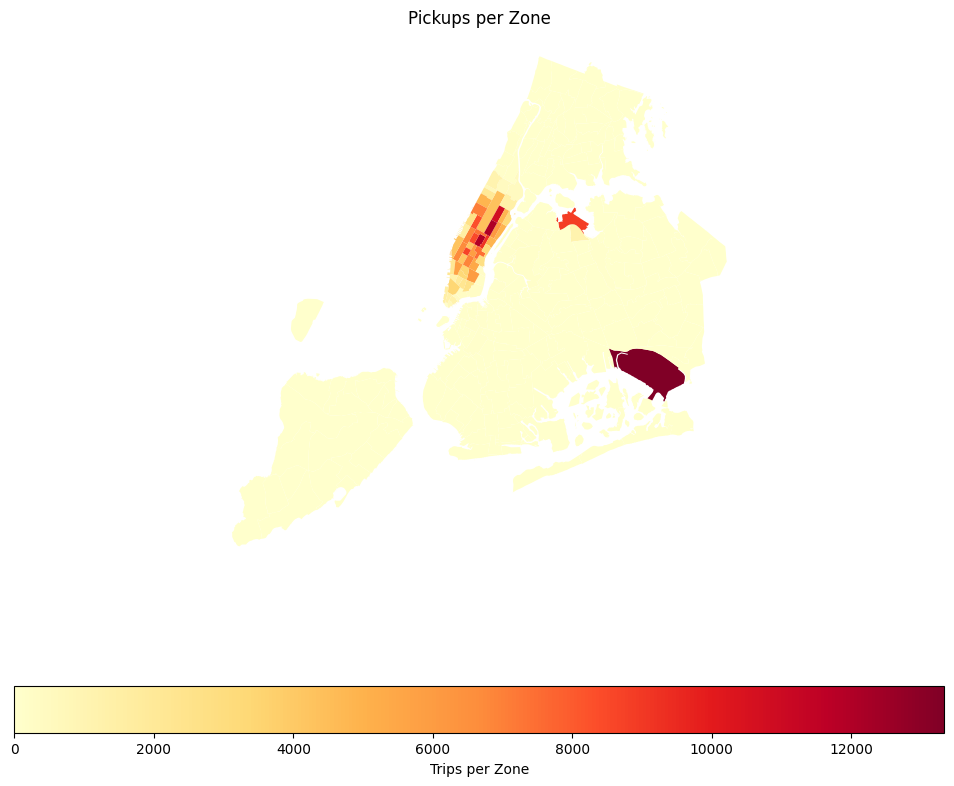

In [53]:
# Define figure and axis


# Plot the map and display it

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot the map and display it
zones_trips.plot(
    column='trip_count',
    ax=ax,
    legend=True,
    cmap='YlOrRd', # Choose a colormap for better visualization
    legend_kwds={'label': "Trips per Zone", 'orientation': "horizontal"}
)
ax.set_title('Pickups per Zone')
ax.set_axis_off() # Hide axes for a cleaner map
plt.show()

In [54]:
# can you try displaying the zones DF sorted by the number of trips?

print("Sorted Trip Count")
print(zones_trips.sort_values(by='trip_count', ascending=False).head(10))

Sorted Trip Count
     OBJECTID  Shape_Leng  Shape_Area                          zone  \
131       132    0.245479    0.002038                   JFK Airport   
236       237    0.042213    0.000096         Upper East Side South   
160       161    0.035804    0.000072                Midtown Center   
235       236    0.044252    0.000103         Upper East Side North   
161       162    0.035270    0.000048                  Midtown East   
137       138    0.107467    0.000537             LaGuardia Airport   
185       186    0.024696    0.000037  Penn Station/Madison Sq West   
229       230    0.031028    0.000056     Times Sq/Theatre District   
141       142    0.038176    0.000076           Lincoln Square East   
169       170    0.045769    0.000074                   Murray Hill   

     LocationID    borough                                           geometry  \
131         132     Queens  MULTIPOLYGON (((1032791.001 181085.006, 103283...   
236         237  Manhattan  POLYGON ((

Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [55]:
# Find routes which have the slowest speeds at different times of the day
# Route analysis based on trip data and zone data

# Add pickup_hour in merged_df
merged_df['pickup_hour'] = merged_df['tpep_pickup_datetime'].dt.hour

# Add trip duration in hour in merged df
merged_df['trip_duration_hours'] = (merged_df['tpep_dropoff_datetime'] - merged_df['tpep_pickup_datetime']).dt.total_seconds() / 3600

# eliminate trips with zero duration or distance to prevent division by zero for speed analysis
df_routes = merged_df[(merged_df['trip_duration_hours'] > 0) & (merged_df['trip_distance'] > 0)].copy()

# addition of speed in dataframe
df_routes['speed'] = df_routes['trip_distance'] / df_routes['trip_duration_hours']

#  average speed for each route at each hour
slowRoutes_analysis = df_routes.groupby(['PULocationID', 'DOLocationID', 'pickup_hour']).agg(
    avg_speed=('speed', 'mean'),
    trip_count=('VendorID', 'count') # Count trips to ensure route is significant
).reset_index()

# elimintae outlier with speed and trip
slowRoutes_analysis = slowRoutes_analysis[slowRoutes_analysis['trip_count'] > 5]

# order the df to identify slow and fast speed
slowest_routes = slowRoutes_analysis.sort_values(by='avg_speed').head(20)

# Merge with zones dataframe to get human-readable zone names
slowest_routes = pd.merge(slowRoutes_analysis, zones[['LocationID', 'zone']], left_on='PULocationID', right_on='LocationID', how='left')
slowest_routes.rename(columns={'zone': 'Pickup Zone'}, inplace=True)
slowest_routes = pd.merge(slowRoutes_analysis, zones[['LocationID', 'zone']], left_on='DOLocationID', right_on='LocationID', how='left')
slowest_routes.rename(columns={'zone': 'Dropoff Zone'}, inplace=True)

slowest_routes.head()

print("Top Slowest Routes (by average speed):")
print(slowest_routes[['Dropoff Zone', 'pickup_hour', 'avg_speed', 'trip_count']].round(2))


Top Slowest Routes (by average speed):
       Dropoff Zone  pickup_hour  avg_speed  trip_count
0      West Village            1       7.67           6
1      Clinton East           16       9.93           8
2      East Chelsea           17      12.90           8
3      East Chelsea           18      12.47           8
4      East Village           18      18.27           8
...             ...          ...        ...         ...
12617           NaN           19      10.78         107
12618           NaN           20      13.81         102
12619           NaN           21      20.47         118
12620           NaN           22      13.71         101
12621           NaN           23      14.42          71

[12622 rows x 4 columns]


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

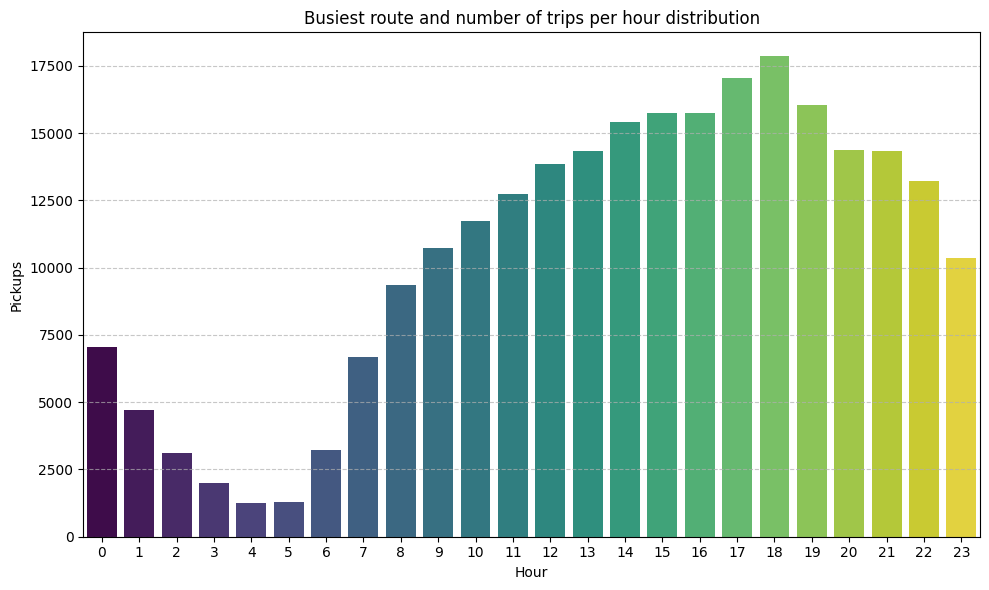

The busiest hour of the day (based on sampled data) is hour 18 with 17850 pickups.


In [57]:
# Visualise the number of trips per hour and find the busiest hour
# busiest route and number of trips per hour distribution


df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
hourly_pickups = df['pickup_hour'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=hourly_pickups.index, y=hourly_pickups.values, palette='viridis', hue=hourly_pickups.index, legend=False)
plt.title('Busiest route and number of trips per hour distribution')
plt.xlabel('Hour')
plt.ylabel('Pickups')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

busiest_hour = hourly_pickups.idxmax()
max_pickups = hourly_pickups.max()

print(f"The busiest hour of the day (based on sampled data) is hour {busiest_hour} with {max_pickups} pickups.")



Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [58]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers

hourly_pickups.sort_index(ascending=False).head(24)



,count
pickup_hour,
23,10369
22,13207
21,14318
20,14380
19,16048
18,17850
17,17052
16,15731
15,15749


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

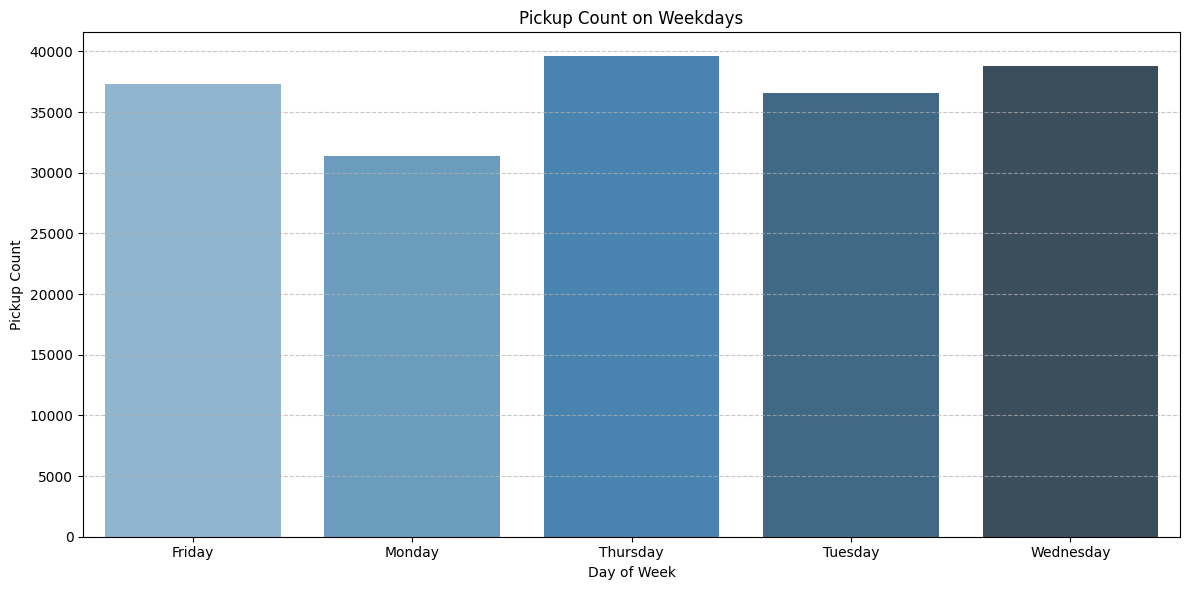

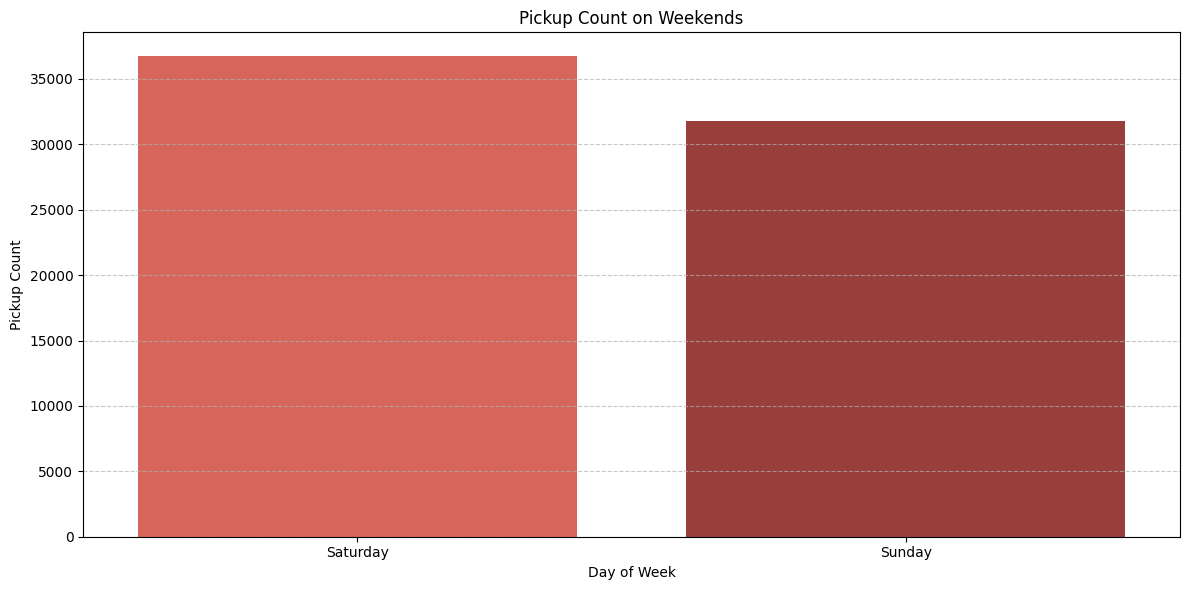

In [59]:
# Compare traffic trends for the week days and weekends

weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
weekends = ['Saturday', 'Sunday']

pickups_weekday = daily_pickups[daily_pickups.index.isin(weekdays)]
pickups_weekend = daily_pickups[daily_pickups.index.isin(weekends)]

plt.figure(figsize=(12, 6))
sns.barplot(x=pickups_weekday.index, y=pickups_weekday.values, palette='Blues_d', hue=pickups_weekday.index, legend=False)
plt.title('Pickup Count on Weekdays')
plt.xlabel('Day of Week')
plt.ylabel('Pickup Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x=pickups_weekend.index, y=pickups_weekend.values, palette='Reds_d', hue=pickups_weekend.index, legend=False)
plt.title('Pickup Count on Weekends')
plt.xlabel('Day of Week')
plt.ylabel('Pickup Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [60]:
# Find top 10 pickup and dropoff zones

# Top 10 Pickup Zones
print("Top 10 Pickup Zones by Trip Count:")
print(trips_zone.head(10))

# Group data by DOLocationID to find the total number of trips per dropoff location ID
drops_zone = merged_df['DOLocationID'].value_counts().reset_index()
drops_zone.columns = ['DOLocationID', 'trip_count']

print("\nTop 10 Dropoff Zones by Trip Count:")
print(drops_zone.head(10))

Top 10 Pickup Zones by Trip Count:
   PULocationID  trip_count
0           132       13336
1           237       12065
2           161       11954
3           236       10749
4           162        9230
5           138        8901
6           186        8679
7           230        8486
8           142        8306
9           170        7493

Top 10 Dropoff Zones by Trip Count:
   DOLocationID  trip_count
0           236       11420
1           237       10700
2           161        9953
3           230        7729
4           170        7566
5           162        7254
6           142        7224
7           239        7128
8           141        6610
9            68        6500


**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [61]:
# Find the top 10 and bottom 10 pickup/dropoff ratios

# Merge pickup counts with zones
zones_with_pickups = pd.merge(zones, trips_zone, left_on='LocationID', right_on='PULocationID', how='left')

# Merge dropoff counts with zones
zones_with_traffic = pd.merge(zones_with_pickups, drops_zone, left_on='LocationID', right_on='DOLocationID', how='left', suffixes=('_pickup', '_dropoff'))

# Fill NaN counts with 0 (for zones with no pickups or dropoffs)
zones_with_traffic['trip_count_pickup'] = zones_with_traffic['trip_count_pickup'].fillna(0)
zones_with_traffic['trip_count_dropoff'] = zones_with_traffic['trip_count_dropoff'].fillna(0)

# Calculate Pickup/Dropoff Ratio, handling division by zero
zones_with_traffic['pickup_dropoff_ratio'] = zones_with_traffic.apply(
    lambda row: row['trip_count_pickup'] / row['trip_count_dropoff'] if row['trip_count_dropoff'] > 0 else (row['trip_count_pickup'] / 1 if row['trip_count_pickup'] > 0 else 0),
    axis=1
)

# Filter out zones with no traffic at all (both pickup and dropoff are 0)
zones_with_traffic = zones_with_traffic[(zones_with_traffic['trip_count_pickup'] > 0) | (zones_with_traffic['trip_count_dropoff'] > 0)]

# Sort and display top 10 ratios
top_10_ratio = zones_with_traffic.sort_values(by='pickup_dropoff_ratio', ascending=False).head(10)
print("\nTop 10 Pickup/Dropoff Ratios (High Pickup, Low Dropoff):")
print(top_10_ratio[['zone', 'trip_count_pickup', 'trip_count_dropoff', 'pickup_dropoff_ratio']])

# Sort and display bottom 10 ratios (excluding 0 if there are significant ones)
bottom_10_ratio = zones_with_traffic[zones_with_traffic['pickup_dropoff_ratio'] > 0].sort_values(by='pickup_dropoff_ratio', ascending=True).head(10)
print("\nBottom 10 Pickup/Dropoff Ratios (Low Pickup, High Dropoff):")
print(bottom_10_ratio[['zone', 'trip_count_pickup', 'trip_count_dropoff', 'pickup_dropoff_ratio']])


Top 10 Pickup/Dropoff Ratios (High Pickup, Low Dropoff):
                             zone  trip_count_pickup  trip_count_dropoff  \
69                  East Elmhurst             1164.0               128.0   
131                   JFK Airport            13336.0              2661.0   
137             LaGuardia Airport             8901.0              3020.0   
185  Penn Station/Madison Sq West             8679.0              5725.0   
42                   Central Park             4372.0              3127.0   
248                  West Village             5701.0              4166.0   
113       Greenwich Village South             3324.0              2468.0   
161                  Midtown East             9230.0              7254.0   
160                Midtown Center            11954.0              9953.0   
99               Garment District             4145.0              3481.0   

     pickup_dropoff_ratio  
69               9.093750  
131              5.011650  
137              2.94

**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [62]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

night_hours = [23, 0, 1, 2, 3, 4, 5]
night_trips_df = merged_df[merged_df['pickup_hour'].isin(night_hours)].copy()

print(f"Number of trips during night hours (11 PM - 5 AM): {len(night_trips_df)}")
night_trips_df.head()

Number of trips during night hours (11 PM - 5 AM): 29779


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,month,trip_duration,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_duration_hours
0,2,2023-02-01 00:14:06,2023-02-01 00:19:52,3.0,1.25,1.0,N,234,114,1,...,2,5.766667,234.0,0.036072,0.000073,Union Sq,234.0,Manhattan,"POLYGON ((987029.847 207022.299, 987048.27 206...",0.096111
1,1,2023-02-01 00:54:09,2023-02-01 01:13:13,1.0,5.00,1.0,N,48,87,1,...,2,19.066667,48.0,0.043747,0.000094,Clinton East,48.0,Manhattan,"POLYGON ((986694.313 214463.846, 986568.184 21...",0.317778
2,2,2023-02-01 00:14:36,2023-02-01 00:59:16,1.0,24.04,1.0,N,114,121,1,...,2,44.666667,114.0,0.031727,0.000047,Greenwich Village South,114.0,Manhattan,"POLYGON ((986306.712 203122.786, 986300.242 20...",0.744444
3,1,2023-02-01 00:49:25,2023-02-01 00:53:12,1.0,0.60,1.0,N,246,68,1,...,2,3.783333,246.0,0.069467,0.000281,West Chelsea/Hudson Yards,246.0,Manhattan,"POLYGON ((983031.177 217138.506, 983640.32 216...",0.063056
4,1,2023-02-01 00:16:02,2023-02-01 00:22:02,1.0,0.90,1.0,N,114,148,1,...,2,6.000000,114.0,0.031727,0.000047,Greenwich Village South,114.0,Manhattan,"POLYGON ((986306.712 203122.786, 986300.242 20...",0.100000


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [63]:
# Filter for night hours (11 PM to 5 AM)

night_hours = [23, 0, 1, 2, 3, 4, 5]
night_trips_df = merged_df[merged_df['pickup_hour'].isin(night_hours)].copy()

print(f"Number of trips during night hours (11 PM - 5 AM): {len(night_trips_df)}")
night_trips_df.head()

Number of trips during night hours (11 PM - 5 AM): 29779


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,month,trip_duration,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_duration_hours
0,2,2023-02-01 00:14:06,2023-02-01 00:19:52,3.0,1.25,1.0,N,234,114,1,...,2,5.766667,234.0,0.036072,0.000073,Union Sq,234.0,Manhattan,"POLYGON ((987029.847 207022.299, 987048.27 206...",0.096111
1,1,2023-02-01 00:54:09,2023-02-01 01:13:13,1.0,5.00,1.0,N,48,87,1,...,2,19.066667,48.0,0.043747,0.000094,Clinton East,48.0,Manhattan,"POLYGON ((986694.313 214463.846, 986568.184 21...",0.317778
2,2,2023-02-01 00:14:36,2023-02-01 00:59:16,1.0,24.04,1.0,N,114,121,1,...,2,44.666667,114.0,0.031727,0.000047,Greenwich Village South,114.0,Manhattan,"POLYGON ((986306.712 203122.786, 986300.242 20...",0.744444
3,1,2023-02-01 00:49:25,2023-02-01 00:53:12,1.0,0.60,1.0,N,246,68,1,...,2,3.783333,246.0,0.069467,0.000281,West Chelsea/Hudson Yards,246.0,Manhattan,"POLYGON ((983031.177 217138.506, 983640.32 216...",0.063056
4,1,2023-02-01 00:16:02,2023-02-01 00:22:02,1.0,0.90,1.0,N,114,148,1,...,2,6.000000,114.0,0.031727,0.000047,Greenwich Village South,114.0,Manhattan,"POLYGON ((986306.712 203122.786, 986300.242 20...",0.100000


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [64]:
# Analyse the fare per mile per passenger for different passenger counts


df_fare_analysis = df_financial.copy()
df_fare_analysis = df_fare_analysis[df_fare_analysis['trip_distance'] > 0]
df_fare_analysis = df_fare_analysis[df_fare_analysis['passenger_count'] > 0]

print(f"Shape of df_fare_analysis after filtering: {df_fare_analysis.shape}")
df_fare_analysis.head()

Shape of df_fare_analysis after filtering: (198056, 24)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_date,pickup_hour,dayofweek,month,quarter
0,2,2023-02-01 00:14:06,2023-02-01 00:19:52,3.0,1.25,1.0,N,234,114,1,...,0.0,1.0,19.72,2.5,0.0,2023-02-01,0,Wednesday,2,1
2,2,2023-02-01 00:14:36,2023-02-01 00:59:16,1.0,24.04,1.0,N,114,121,1,...,0.0,1.0,102.20,2.5,0.0,2023-02-01,0,Wednesday,2,1
3,1,2023-02-01 00:49:25,2023-02-01 00:53:12,1.0,0.60,1.0,N,246,68,1,...,0.0,1.0,11.80,2.5,0.0,2023-02-01,0,Wednesday,2,1
4,1,2023-02-01 00:16:02,2023-02-01 00:22:02,1.0,0.90,1.0,N,114,148,1,...,0.0,1.0,15.45,2.5,0.0,2023-02-01,0,Wednesday,2,1
5,2,2023-02-01 00:08:39,2023-02-01 00:10:50,3.0,0.53,1.0,N,263,263,1,...,0.0,1.0,11.18,2.5,0.0,2023-02-01,0,Wednesday,2,1


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [65]:
# Compare the average fare per mile for different days and for different times of the day
df_financial['fare_per_mile'] = df_financial['fare_amount'] / df_financial['trip_distance']
df_financial.head()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_date,pickup_hour,dayofweek,month,quarter,fare_per_mile
0,2,2023-02-01 00:14:06,2023-02-01 00:19:52,3.0,1.25,1.0,N,234,114,1,...,1.0,19.72,2.5,0.0,2023-02-01,0,Wednesday,2,1,6.880000
2,2,2023-02-01 00:14:36,2023-02-01 00:59:16,1.0,24.04,1.0,N,114,121,1,...,1.0,102.20,2.5,0.0,2023-02-01,0,Wednesday,2,1,3.793677
3,1,2023-02-01 00:49:25,2023-02-01 00:53:12,1.0,0.60,1.0,N,246,68,1,...,1.0,11.80,2.5,0.0,2023-02-01,0,Wednesday,2,1,9.666667
4,1,2023-02-01 00:16:02,2023-02-01 00:22:02,1.0,0.90,1.0,N,114,148,1,...,1.0,15.45,2.5,0.0,2023-02-01,0,Wednesday,2,1,8.777778
5,2,2023-02-01 00:08:39,2023-02-01 00:10:50,3.0,0.53,1.0,N,263,263,1,...,1.0,11.18,2.5,0.0,2023-02-01,0,Wednesday,2,1,9.622642


**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

In [66]:
# Compare fare per mile for different vendors
df_financial['fare_per_mile'] = df_financial['fare_amount'] / df_financial['trip_distance']

# Group by VendorID and calculate the average fare_per_mile
average_fare_per_mile_by_vendor = df_financial.groupby('VendorID')['fare_per_mile'].mean().reset_index()

print("Average Fare Per Mile by Vendor:")
print(average_fare_per_mile_by_vendor)


Average Fare Per Mile by Vendor:
   VendorID  fare_per_mile
0         1       7.837783
1         2       9.938359


**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [67]:
# Defining distance tiers

bins = [-0.1, 1, 3, 10, df_financial['trip_distance'].max()]
labels = ['Short Trip (0-1 mi)', 'Medium Trip (1-3 mi)', 'Long Trip (3-10 mi)', 'Very Long Trip (>10 mi)']

df_financial['distance_tier'] = pd.cut(df_financial['trip_distance'], bins=bins, labels=labels, right=True)

print("Distribution of distance tiers:")
print(df_financial['distance_tier'].value_counts())
print("\nFirst 5 rows with new 'distance_tier' column:")
print(df_financial[['trip_distance', 'distance_tier']].head())

Distribution of distance tiers:
distance_tier
Medium Trip (1-3 mi)       99805
Short Trip (0-1 mi)        42510
Long Trip (3-10 mi)        39574
Very Long Trip (>10 mi)    16167
Name: count, dtype: int64

First 5 rows with new 'distance_tier' column:
   trip_distance            distance_tier
0           1.25     Medium Trip (1-3 mi)
2          24.04  Very Long Trip (>10 mi)
3           0.60      Short Trip (0-1 mi)
4           0.90      Short Trip (0-1 mi)
5           0.53      Short Trip (0-1 mi)


##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [68]:
#  Analyze tip percentages based on distances, passenger counts and pickup times

df_financial['tip_percentage'] = df_financial.apply(lambda row: (row['tip_amount'] / row['fare_amount']) * 100 if row['fare_amount'] > 0 else 0, axis=1)
df_financial.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,congestion_surcharge,Airport_fee,pickup_date,pickup_hour,dayofweek,month,quarter,fare_per_mile,distance_tier,tip_percentage
0,2,2023-02-01 00:14:06,2023-02-01 00:19:52,3.0,1.25,1.0,N,234,114,1,...,2.5,0.0,2023-02-01,0,Wednesday,2,1,6.880000,Medium Trip (1-3 mi),71.162791
2,2,2023-02-01 00:14:36,2023-02-01 00:59:16,1.0,24.04,1.0,N,114,121,1,...,2.5,0.0,2023-02-01,0,Wednesday,2,1,3.793677,Very Long Trip (>10 mi),6.578947
3,1,2023-02-01 00:49:25,2023-02-01 00:53:12,1.0,0.60,1.0,N,246,68,1,...,2.5,0.0,2023-02-01,0,Wednesday,2,1,9.666667,Short Trip (0-1 mi),17.241379
4,1,2023-02-01 00:16:02,2023-02-01 00:22:02,1.0,0.90,1.0,N,114,148,1,...,2.5,0.0,2023-02-01,0,Wednesday,2,1,8.777778,Short Trip (0-1 mi),32.278481
5,2,2023-02-01 00:08:39,2023-02-01 00:10:50,3.0,0.53,1.0,N,263,263,1,...,2.5,0.0,2023-02-01,0,Wednesday,2,1,9.622642,Short Trip (0-1 mi),21.176471


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [69]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%

low_tip_trips = df_financial[df_financial['tip_percentage'] < 10]
high_tip_trips = df_financial[df_financial['tip_percentage'] > 25]

print("Low Tip Trips (tip_percentage < 10%):")
print(low_tip_trips.head())

print("\nHigh Tip Trips (tip_percentage > 25%):")
print(high_tip_trips.head())

Low Tip Trips (tip_percentage < 10%):
     VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
2           2  2023-02-01 00:14:36   2023-02-01 00:59:16              1.0   
13          2  2023-02-01 01:52:26   2023-02-01 02:02:43              1.0   
55          2  2023-02-01 07:25:28   2023-02-01 07:42:24              1.0   
63          1  2023-02-01 07:57:18   2023-02-01 09:20:59              1.0   
106         2  2023-02-01 09:17:51   2023-02-01 09:31:49              1.0   

     trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
2            24.04         1.0                  N           114           121   
13            2.73         1.0                  N           100           263   
55            8.50         1.0                  N           143           127   
63           18.00         2.0                  N           132           230   
106           2.52         1.0                  N           141           233   

     payment

**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

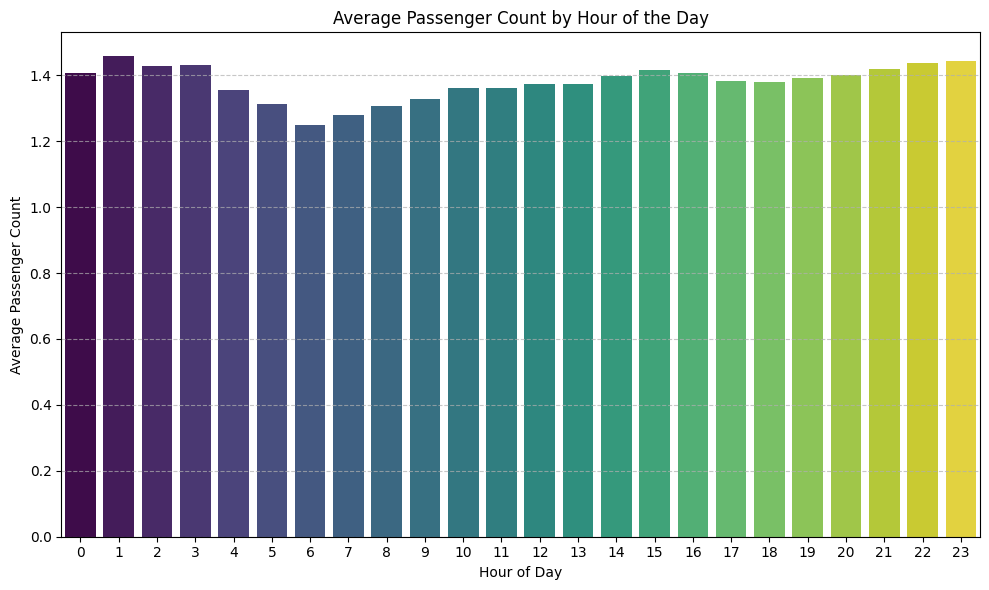

Average Passenger Count by Hour:
pickup_hour
0     1.405842
1     1.457415
2     1.429033
3     1.432351
4     1.354660
5     1.313480
6     1.249072
7     1.278792
8     1.306490
9     1.327173
10    1.362651
11    1.362517
12    1.374512
13    1.374216
14    1.398532
15    1.414566
16    1.406776
17    1.382008
18    1.379832
19    1.392884
20    1.399930
21    1.417796
22    1.438707
23    1.443051
Name: passenger_count, dtype: float64


In [70]:
# See how passenger count varies across hours and days


# Analyze Average Passenger Count by Hour
average_passenger_count_hourly = df.groupby('pickup_hour')['passenger_count'].mean()

# Visualize the trend
plt.figure(figsize=(10, 6))
sns.barplot(x=average_passenger_count_hourly.index, y=average_passenger_count_hourly.values, palette='viridis', hue=average_passenger_count_hourly.index, legend=False)
plt.title('Average Passenger Count by Hour of the Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Passenger Count')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Average Passenger Count by Hour:")
print(average_passenger_count_hourly)



**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [71]:
# How does passenger count vary across zones

avg_passenger_count_per_zone = merged_df.groupby('PULocationID')['passenger_count'].mean().reset_index()
avg_passenger_count_per_zone.columns = ['PULocationID', 'avg_pickup_passenger_count']
print(avg_passenger_count_per_zone.head())

   PULocationID  avg_pickup_passenger_count
0             1                    2.000000
1             4                    1.378151
2             6                    2.000000
3             7                    1.225806
4             9                    1.000000


In [72]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.

avg_passenger_count_per_zone = merged_df.groupby('PULocationID')['passenger_count'].mean().reset_index()
avg_passenger_count_per_zone.rename(columns={'passenger_count': 'avg_pickup_passenger_count'}, inplace=True)

zones_trips = pd.merge(zones_trips, avg_passenger_count_per_zone, left_on='LocationID', right_on='PULocationID', how='left')
zones_trips['avg_pickup_passenger_count'] = zones_trips['avg_pickup_passenger_count'].fillna(0)

print("Zones GeoDataFrame with average passenger count per zone (head):")
print(zones_trips.head())

Zones GeoDataFrame with average passenger count per zone (head):
   OBJECTID  Shape_Leng  Shape_Area                     zone  LocationID  \
0         1    0.116357    0.000782           Newark Airport           1   
1         2    0.433470    0.004866              Jamaica Bay           2   
2         3    0.084341    0.000314  Allerton/Pelham Gardens           3   
3         4    0.043567    0.000112            Alphabet City           4   
4         5    0.092146    0.000498            Arden Heights           5   

         borough                                           geometry  \
0            EWR  POLYGON ((933100.918 192536.086, 933091.011 19...   
1         Queens  MULTIPOLYGON (((1033269.244 172126.008, 103343...   
2          Bronx  POLYGON ((1026308.77 256767.698, 1026495.593 2...   
3      Manhattan  POLYGON ((992073.467 203714.076, 992068.667 20...   
4  Staten Island  POLYGON ((935843.31 144283.336, 936046.565 144...   

   PULocationID_x  trip_count  PULocationID_y  avg_

Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [73]:
# How often is each surcharge applied?

surcharge_columns = [
    'extra',
    'mta_tax',
    'tolls_amount',
    'improvement_surcharge',
    'congestion_surcharge',
    'Airport_fee'
]

surcharge_application_counts = {}

for column in surcharge_columns:
    applied_count = df[df[column] > 0].shape[0]
    surcharge_application_counts[column] = applied_count

print("Surcharge Application Frequency:")
for column, count in surcharge_application_counts.items():
    print(f"{column}: {count} trips")

Surcharge Application Frequency:
extra: 157830 trips
mta_tax: 250517 trips
tolls_amount: 20241 trips
improvement_surcharge: 252089 trips
congestion_surcharge: 235498 trips
Airport_fee: 22308 trips


## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.